In [1]:
import pandas as pd
user_category_df = pd.read_csv(r"D:\내 자료실(이동,삭제 절대금지~~!!)\Desktop\data analysis\Proj_1 e_cummerce\Python\user.csv")

In [2]:
user_category_df.head()

,user_id,product_cnt,category_cnt,purchase_flag,purchase_category_cnt
0,10300217,1,1,0,0
1,29515875,5,2,0,0
2,31198833,18,3,0,0
3,34916060,1,1,0,0
4,41798457,1,1,0,0


In [3]:
# 그래프 그리기 위한 임시 데이터 프레임

tmp = (
    user_category_df.groupby("category_cnt")["purchase_flag"]
      .mean()
      .reset_index()
)

In [4]:
# category_cnt 극단조사

user_category_df["category_cnt"].quantile([0.99, 0.995, 0.999])

0.990    19.0
0.995    25.0
0.999    39.0
Name: category_cnt, dtype: float64

In [5]:
pd.set_option('display.max_rows', 200)

In [6]:
# category_cnt 이상치 찾기 (category_cnt가 커지면 평균내기위한 표본이 적어짐)

tmp_cnt = (
    user_category_df.groupby("category_cnt")
      .size()
      .reset_index(name="user_cnt")
)
tmp_cnt

,category_cnt,user_cnt
0,1,1938281
1,2,615702
2,3,329445
3,4,207572
4,5,140623
5,6,100467
6,7,73658
7,8,55677
8,9,43208
9,10,33467


In [7]:
# category_cnt 한계치 설정 (99.9% 이내)

tmp = tmp[tmp["category_cnt"] <= 39]

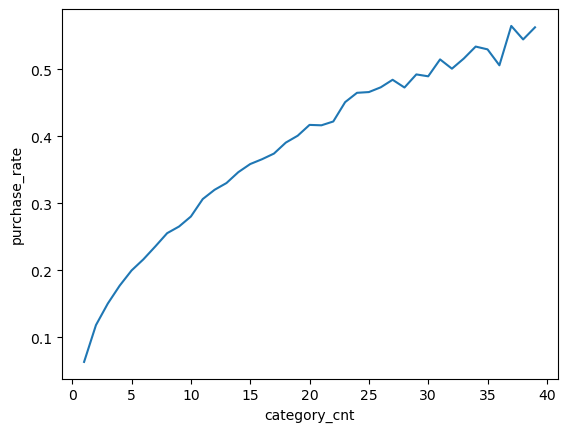

In [8]:
# category_cnt 와 purchase_rate의 관계

import matplotlib.pyplot as plt

plt.plot(
    tmp["category_cnt"],
    tmp["purchase_flag"]
)

plt.xlabel("category_cnt")
plt.ylabel("purchase_rate")

plt.show()

In [9]:
# 탐색 카테고리 수에 대한 구매의사 보정치

user_category_df["purchase_flag_c"]=user_category_df["purchase_category_cnt"]/user_category_df["category_cnt"]

In [10]:
# 그래프 그리기 위한 임시 데이터 프레임

tmp2 = (
    user_category_df.groupby("category_cnt")["purchase_flag_c"]
      .mean()
      .reset_index()
)

tmp2 = tmp2[tmp2["category_cnt"] <= 39]

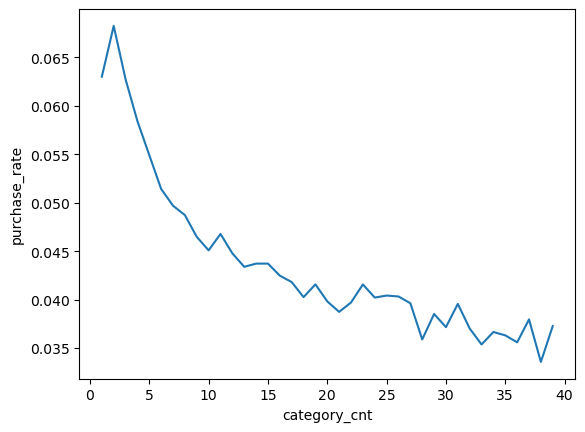

In [11]:
# category_cnt 와 purchase_rate (보정치) 의 관계

import matplotlib.pyplot as plt

plt.plot(
    tmp2["category_cnt"],
    tmp2["purchase_flag_c"]
)

plt.xlabel("category_cnt")
plt.ylabel("purchase_rate")

plt.show()